# Demo 04 — Reranking & Hybrid Search

The runnable notebook behind **§8.1–§8.3** of *Chapter 04 — Inference-Time Retrieval Patterns*: the
layers that turn Naive RAG into Advanced RAG. We stack retrieval stages on `ragqa_arena_tech` and
measure recall@k at each step:

`BM25 (lexical)` → `dense (embeddings)` → `hybrid (RRF)` → `+ cross-encoder` → `+ LLM pointwise` →
`+ LLM listwise (RankGPT)`.

The chapter's claim to verify (§8.3): *hybrid > each single retriever; the cross-encoder gives a big
jump at low k; the LLM listwise reranker is usually highest of all — at a fraction of pointwise's calls.*

**Corpus.** Same `ragqa_arena_tech` running example as §3–§5; whole-document retrieval, multi-relevant
`gold_doc_ids`. To keep the LLM stages cheap we evaluate on a sample of queries against a corpus
subset that always contains their gold documents — so the absolute recall here runs higher than the
full-28k numbers in §4–§5; read the **stage-to-stage deltas**, not the absolutes.

**Keys.** The BM25 / dense / hybrid / cross-encoder stages are local (no key). The two **LLM**
reranking stages call **Claude** (`ANTHROPIC_API_KEY` in `.env`); they skip gracefully if no key is set.

**Cost.** The LLM stages make ~880 Claude Haiku calls (pointwise 80×10 + listwise 80) — roughly
**$1**, once: results are cached to `rerankers_cache/`, so re-runs are free.

## Part 1 — Setup

macOS notes (as in the other demos): MPS segfaults for this torch build, so we run on **CPU locally**
(on Colab, `DEVICE` auto-selects the GPU); `torch` + `faiss`/tokenizers ship clashing OpenMP runtimes,
so we allow the duplicate. A Colab T4 GPU makes the embedding + cross-encoder stages near-instant.

In [ ]:
# Dependencies (uncomment on Colab or a fresh environment):
# !pip install datasets sentence-transformers rank_bm25 anthropic python-dotenv matplotlib pandas
# On Colab: Runtime -> Change runtime type -> T4 GPU.

In [26]:
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import json
import time
import random
import asyncio
from collections import deque
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from dotenv import load_dotenv
from sentence_transformers import SentenceTransformer, CrossEncoder
from rank_bm25 import BM25Okapi
import anthropic

load_dotenv()
# On Colab, pull the key from Colab Secrets (sidebar key icon) if it isn't already in the env.
if not os.environ.get("ANTHROPIC_API_KEY"):
    try:
        from google.colab import userdata
        os.environ["ANTHROPIC_API_KEY"] = userdata.get("ANTHROPIC_API_KEY")
    except Exception:
        pass

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"   # MPS segfaults; use CPU/GPU

# MiniLM is ragqa's best dense retriever (§5.2) and needs no query/passage prefix.
EMB_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
CE_MODEL = "cross-encoder/ms-marco-MiniLM-L-6-v2"
LLM_MODEL = "claude-haiku-4-5-20251001"

N_QUERIES = 80      # evaluation queries (kept small so the LLM stages stay cheap)
N_DOCS = 6000       # corpus subset: all gold docs for the sampled queries + distractors
RERANK_N = 20       # candidates from hybrid that the cross-encoder re-scores
POINTWISE_TOPK = 10 # candidates the pointwise LLM scores (N calls/query)
LISTWISE_N = 10     # candidates the listwise LLM reorders (1 call/query)
RPM_LIMIT = 200     # Claude requests/min for the rate limiter
LLM_CONCURRENCY = 8

CACHE = Path("rerankers_cache")
CACHE.mkdir(exist_ok=True)
HAVE_KEY = bool(os.environ.get("ANTHROPIC_API_KEY"))
print(f"device: {DEVICE} | Claude key present: {HAVE_KEY}")

device: cuda | Claude key present: True


## Part 2 — Build the evaluation set

Sample queries from `ragqa_arena_tech`, then build a corpus subset that always contains their gold
documents plus random distractors (so recall is meaningful without embedding all ~28k docs). Gold
ids are the corpus **line positions**; we remap them to positions within the subset.

In [27]:
import urllib.request

HF_BASE = "https://huggingface.co/dspy/cache/resolve/main/"
for fn in ["ragqa_arena_tech_corpus.jsonl", "ragqa_arena_tech_examples.jsonl"]:
    if not Path(fn).exists():
        print(f"downloading {fn} ...")
        urllib.request.urlretrieve(HF_BASE + fn, fn)

corpus = [json.loads(line)["text"] for line in open("ragqa_arena_tech_corpus.jsonl")]
examples = [json.loads(line) for line in open("ragqa_arena_tech_examples.jsonl")]

usable = [e for e in examples if any(0 <= g < len(corpus) for g in e["gold_doc_ids"])]
sample = random.sample(usable, N_QUERIES)

gold_needed = set()
for e in sample:
    gold_needed |= {g for g in e["gold_doc_ids"] if 0 <= g < len(corpus)}

others = [i for i in range(len(corpus)) if i not in gold_needed]
distractors = random.sample(others, min(N_DOCS - len(gold_needed), len(others)))
subset_ids = sorted(gold_needed | set(distractors))
pos = {doc_id: p for p, doc_id in enumerate(subset_ids)}   # corpus id -> subset position

passages = [corpus[i] for i in subset_ids]
questions = [e["question"] for e in sample]
gold = [{pos[g] for g in e["gold_doc_ids"] if g in pos} for e in sample]

print(f"{len(questions)} queries | {len(passages):,} passages | "
      f"avg gold/query: {np.mean([len(g) for g in gold]):.2f}")

80 queries | 6,000 passages | avg gold/query: 4.39


## Part 3 — Metric: recall@k

Multi-relevant recall (ragqa has several gold docs per query): the fraction of a query's gold
documents that land in the top-k of a ranking.

In [28]:
def recall_at_k(ranking, rel, k):
    return len(set(ranking[:k]) & rel) / len(rel) if rel else 0.0

def headline(rankings, ks=(1, 3, 5, 10)):
    return {f"recall@{k}": float(np.mean([recall_at_k(r, g, k) for r, g in zip(rankings, gold)]))
            for k in ks}

def recall_curve(rankings, ks=range(1, 11)):
    return [float(np.mean([recall_at_k(r, g, k) for r, g in zip(rankings, gold)])) for k in ks]

def plot_curves(curves, title):
    plt.figure(figsize=(9, 5))
    for label, ys in curves.items():
        plt.plot(range(1, 11), ys, marker="o", label=label)
    plt.xlabel("k"); plt.ylabel("recall@k"); plt.title(title)
    plt.ylim(0, 1.02); plt.grid(True, alpha=0.3); plt.legend(loc="lower right")
    plt.tight_layout(); plt.show()

## Part 4 — BM25 (sparse, lexical) — §8.1

BM25 ranks by exact term overlap. Strong on rare tokens (names, IDs, error codes), blind to
synonyms and paraphrase.

In [29]:
tokenize = lambda s: s.lower().split()
bm25 = BM25Okapi([tokenize(p) for p in passages])

bm25_ranks = [np.argsort(-bm25.get_scores(tokenize(q))).tolist() for q in questions]
bm25_m = headline(bm25_ranks)
print("BM25:", {k: round(v, 3) for k, v in bm25_m.items()})

BM25: {'recall@1': 0.164, 'recall@3': 0.28, 'recall@5': 0.361, 'recall@10': 0.446}


## Part 5 — Dense (embeddings) — §8.1

A bi-encoder embeds query and passage independently, then ranks by cosine. Strong on paraphrase,
weaker on exact tokens — the complement of BM25. We use `all-MiniLM-L6-v2`, the model that won the
embedding-knob comparison on ragqa (§5.2) and needs no query/passage prefix.

In [30]:
emb_model = SentenceTransformer(EMB_MODEL, device=DEVICE)

emb_path = CACHE / f"passages_{len(passages)}_{EMB_MODEL.split('/')[-1]}.npy"
if emb_path.exists():
    doc_emb = np.load(emb_path)
else:
    doc_emb = emb_model.encode(passages, batch_size=256, normalize_embeddings=True,
                               convert_to_numpy=True, show_progress_bar=False).astype(np.float32)
    np.save(emb_path, doc_emb)

q_emb = emb_model.encode(questions, batch_size=256, normalize_embeddings=True,
                         convert_to_numpy=True, show_progress_bar=False).astype(np.float32)
dense_ranks = [np.argsort(-(q_emb[i] @ doc_emb.T)).tolist() for i in range(len(questions))]
dense_m = headline(dense_ranks)
print("Dense:", {k: round(v, 3) for k, v in dense_m.items()})

Dense: {'recall@1': 0.343, 'recall@3': 0.587, 'recall@5': 0.702, 'recall@10': 0.793}


## Part 6 — Hybrid via Reciprocal Rank Fusion (RRF) — §8.1

RRF ignores raw scores and fuses on *position*: a document scores `Σ 1/(k0 + rank)` across rankers,
so agreement across BM25 and dense beats a strong rank in either alone.

In [31]:
def rrf_fuse(rank_lists, k0=60):
    scores = {}
    for ranks in rank_lists:
        for rank, doc in enumerate(ranks):
            scores[doc] = scores.get(doc, 0.0) + 1.0 / (k0 + rank + 1)
    return [d for d, _ in sorted(scores.items(), key=lambda x: -x[1])]

hybrid_ranks = [rrf_fuse([bm25_ranks[i], dense_ranks[i]]) for i in range(len(questions))]
hybrid_m = headline(hybrid_ranks)
print("Hybrid (RRF):", {k: round(v, 3) for k, v in hybrid_m.items()})

# Rerankers rescore the BEST retriever's candidates. The textbook pipeline reranks the
# fused (hybrid) set; on ragqa hybrid underperforms dense, so we rerank dense's pool instead.
base_ranks, BASE_NAME = dense_ranks, "dense"

Hybrid (RRF): {'recall@1': 0.293, 'recall@3': 0.466, 'recall@5': 0.549, 'recall@10': 0.664}


## Part 7 — Cross-encoder rerank — §8.2

A cross-encoder reads (query, passage) **jointly** and attends across the boundary — information a
bi-encoder discards. It is too slow for first-stage retrieval, so we apply it only to the top
`RERANK_N` candidates of the **best retriever**. The textbook pipeline reranks the *fused* (hybrid)
set, but on ragqa hybrid underperforms dense, and a reranker can never beat its pool's recall
ceiling — so we rerank **dense's** candidates instead.

In [32]:
ce_model = CrossEncoder(CE_MODEL, device=DEVICE)

ce_ranks = []
for i, q in enumerate(questions):
    cand = base_ranks[i][:RERANK_N]
    scores = ce_model.predict([(q, passages[d]) for d in cand])
    reranked = [cand[j] for j in np.argsort(-scores)]
    tail = [d for d in base_ranks[i] if d not in set(cand)]
    ce_ranks.append(reranked + tail)

ce_m = headline(ce_ranks)
print("+ Cross-encoder:", {k: round(v, 3) for k, v in ce_m.items()})

+ Cross-encoder: {'recall@1': 0.312, 'recall@3': 0.563, 'recall@5': 0.663, 'recall@10': 0.783}


## Part 8 — LLM reranker, pointwise — §8.3

Replace the cross-encoder with Claude, scoring each (query, passage) pair 1–5 via forced tool use.
The drop-in for a cross-encoder, but with three weaknesses: N calls per query, score saturation
(too many 5s), and per-candidate myopia. Runs async with a rate limiter; results are cached.

In [33]:
POINTWISE_TOOL = {
    "name": "submit_score",
    "description": "Submit a relevance score for one (query, passage) pair.",
    "input_schema": {
        "type": "object",
        "properties": {"score": {"type": "integer", "minimum": 1, "maximum": 5,
                                 "description": "1 = irrelevant, 5 = directly answers the query."}},
        "required": ["score"],
    },
}
POINTWISE_PROMPT = """You are a search relevance judge. Score how relevant the passage is to the query on a 1-5 scale:
5 = directly answers the query
4 = highly related, contains supporting info
3 = topically related but does not answer
2 = weakly related
1 = unrelated

Query: {query}

Passage: {passage}

Call submit_score with your integer rating."""


class RateLimiter:
    """Sliding-window RPM limiter; await acquire() before each request."""
    def __init__(self, rpm, window=60.0):
        self.rpm, self.window = rpm, window
        self.times, self.lock = deque(), asyncio.Lock()

    async def acquire(self):
        while True:
            async with self.lock:
                now = time.monotonic()
                while self.times and now - self.times[0] >= self.window:
                    self.times.popleft()
                if len(self.times) < self.rpm:
                    self.times.append(now); return
                wait = self.window - (now - self.times[0]) + 0.05
            await asyncio.sleep(wait)

In [34]:
async def pointwise_score(client, limiter, sem, query, passage):
    async with sem:
        await limiter.acquire()
        try:
            msg = await client.messages.create(
                model=LLM_MODEL, max_tokens=128, tools=[POINTWISE_TOOL],
                tool_choice={"type": "tool", "name": "submit_score"},
                messages=[{"role": "user",
                           "content": POINTWISE_PROMPT.format(query=query, passage=passage)}])
            for b in msg.content:
                if b.type == "tool_use":
                    return int(b.input["score"])
        except Exception as e:
            return None
    return None

async def run_pointwise():
    client = anthropic.AsyncAnthropic(max_retries=10)
    limiter, sem = RateLimiter(RPM_LIMIT), asyncio.Semaphore(LLM_CONCURRENCY)
    jobs = [pointwise_score(client, limiter, sem, questions[i], passages[d])
            for i in range(len(questions)) for d in base_ranks[i][:POINTWISE_TOPK]]
    flat = await asyncio.gather(*jobs)
    scores, idx = [], 0
    for i in range(len(questions)):
        n = len(base_ranks[i][:POINTWISE_TOPK])
        scores.append(flat[idx:idx + n]); idx += n
    return scores

def pointwise_ranking(i, scores):
    cand = base_ranks[i][:POINTWISE_TOPK]
    order = sorted(range(len(cand)),
                   key=lambda j: (-(scores[j] if scores[j] is not None else -1), j))
    head = [cand[j] for j in order]
    return head + [d for d in base_ranks[i] if d not in set(cand)]

pw_cache = CACHE / f"pointwise_{BASE_NAME}_{N_QUERIES}.json"
pw_m, pw_ranks = None, None
if pw_cache.exists():
    pw_scores = json.load(open(pw_cache))
    pw_ranks = [pointwise_ranking(i, pw_scores[i]) for i in range(len(questions))]
    pw_m = headline(pw_ranks)
    print("+ LLM pointwise (cached):", {k: round(v, 3) for k, v in pw_m.items()})
elif HAVE_KEY:
    print(f"submitting ~{len(questions) * POINTWISE_TOPK} pointwise calls ...")
    pw_scores = await run_pointwise()
    json.dump(pw_scores, open(pw_cache, "w"))
    pw_ranks = [pointwise_ranking(i, pw_scores[i]) for i in range(len(questions))]
    pw_m = headline(pw_ranks)
    print("+ LLM pointwise:", {k: round(v, 3) for k, v in pw_m.items()})
else:
    print("No ANTHROPIC_API_KEY — skipping the pointwise LLM stage.")

submitting ~800 pointwise calls ...
+ LLM pointwise: {'recall@1': 0.361, 'recall@3': 0.665, 'recall@5': 0.751, 'recall@10': 0.793}


## Part 9 — LLM reranker, listwise (RankGPT) — §8.3

Send the whole numbered candidate list in **one** call and ask for the permutation. Relative
judgments ("passage 7 beats passage 3") are easier than absolute scores, it is tail-aware, and it
costs 1/N the calls of pointwise. We validate and repair the returned permutation.

In [35]:
LISTWISE_TOOL = {
    "name": "submit_ranking",
    "description": "Re-order the candidates by relevance to the query.",
    "input_schema": {
        "type": "object",
        "properties": {"order": {"type": "array", "items": {"type": "integer"},
                                 "description": "Permutation of 1..N, most relevant first; each once."}},
        "required": ["order"],
    },
}
LISTWISE_PROMPT = """You are a search relevance judge. Re-rank the following {n} passages by relevance to the query, most relevant first.

Query: {query}

Candidates:
{candidates}

Call submit_ranking with the permutation of [1..{n}]. Every number 1..{n} must appear exactly once."""

def format_candidates(texts, max_chars=600):
    return "\n\n".join(f"[{i + 1}] {t[:max_chars]}" for i, t in enumerate(texts))

async def listwise_rerank(client, limiter, sem, query, cand_texts):
    n = len(cand_texts)
    async with sem:
        await limiter.acquire()
        try:
            msg = await client.messages.create(
                model=LLM_MODEL, max_tokens=1024, tools=[LISTWISE_TOOL],
                tool_choice={"type": "tool", "name": "submit_ranking"},
                messages=[{"role": "user", "content": LISTWISE_PROMPT.format(
                    query=query, n=n, candidates=format_candidates(cand_texts))}])
            for b in msg.content:
                if b.type == "tool_use":
                    order = [int(x) - 1 for x in b.input["order"]]
                    seen, fixed = set(), []
                    for x in order:
                        if 0 <= x < n and x not in seen:
                            seen.add(x); fixed.append(x)
                    fixed += [x for x in range(n) if x not in seen]
                    return fixed
        except Exception:
            pass
    return list(range(n))

async def run_listwise():
    client = anthropic.AsyncAnthropic(max_retries=10)
    limiter, sem = RateLimiter(RPM_LIMIT), asyncio.Semaphore(LLM_CONCURRENCY)
    async def one(i):
        cand = base_ranks[i][:LISTWISE_N]
        order = await listwise_rerank(client, limiter, sem, questions[i], [passages[d] for d in cand])
        head = [cand[j] for j in order]
        return head + [d for d in base_ranks[i] if d not in set(cand)]
    return await asyncio.gather(*[one(i) for i in range(len(questions))])

lw_cache = CACHE / f"listwise_{BASE_NAME}_{N_QUERIES}.json"
lw_m, lw_ranks = None, None
if lw_cache.exists():
    lw_ranks = json.load(open(lw_cache))
    lw_m = headline(lw_ranks)
    print("+ LLM listwise (cached):", {k: round(v, 3) for k, v in lw_m.items()})
elif HAVE_KEY:
    print(f"submitting {len(questions)} listwise calls ...")
    lw_ranks = await run_listwise()
    json.dump(lw_ranks, open(lw_cache, "w"))
    lw_m = headline(lw_ranks)
    print("+ LLM listwise:", {k: round(v, 3) for k, v in lw_m.items()})
else:
    print("No ANTHROPIC_API_KEY — skipping the listwise LLM stage.")

submitting 80 listwise calls ...
+ LLM listwise: {'recall@1': 0.368, 'recall@3': 0.647, 'recall@5': 0.745, 'recall@10': 0.793}


## Part 10 — Leaderboard

Stack every stage. The transferable lesson is the **ordering**, not the exact digits (they shift
with corpus and sample). Compare against the chapter's §8.3 claim.

stage  recall@1  recall@3  recall@5  recall@10
           BM25     0.164     0.280     0.361      0.446
          Dense     0.343     0.587     0.702      0.793
   Hybrid (RRF)     0.293     0.466     0.549      0.664
+ Cross-encoder     0.312     0.563     0.663      0.783
+ LLM pointwise     0.361     0.665     0.751      0.793
 + LLM listwise     0.368     0.647     0.745      0.793


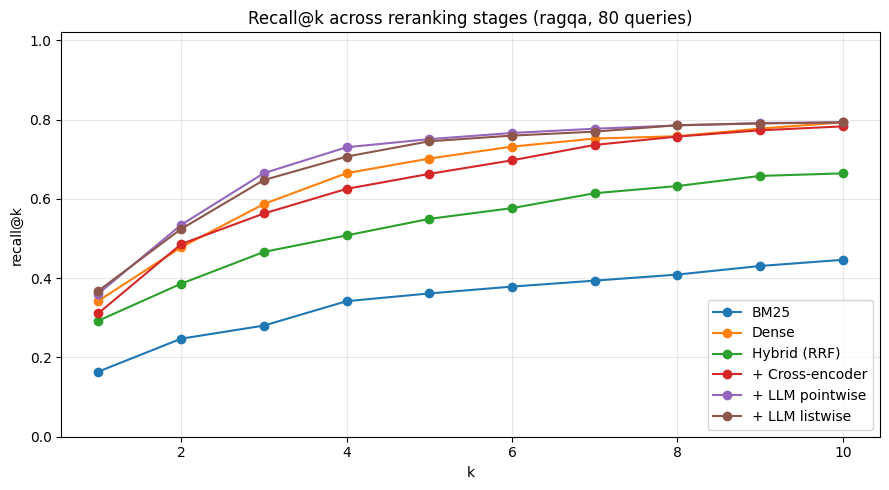

In [36]:
stages = [("BM25", bm25_m, bm25_ranks), ("Dense", dense_m, dense_ranks),
          ("Hybrid (RRF)", hybrid_m, hybrid_ranks), ("+ Cross-encoder", ce_m, ce_ranks),
          ("+ LLM pointwise", pw_m, pw_ranks), ("+ LLM listwise", lw_m, lw_ranks)]

rows = [{"stage": name, **{k: round(v, 3) for k, v in m.items()}}
        for name, m, _ in stages if m is not None]
print(pd.DataFrame(rows).to_string(index=False))

plot_curves({name: recall_curve(r) for name, m, r in stages if m is not None},
            title=f"Recall@k across reranking stages (ragqa, {N_QUERIES} queries)")

## Summary

These are the *expected* patterns from the literature — read them against the leaderboard you just
produced, because (as §5 showed) a specific corpus can upend the textbook ordering:

- **Hybrid (RRF)** fuses lexical and semantic retrieval and usually beats either alone (§8.1).
- A **cross-encoder** rerank of the top candidates is the cheap, high-leverage second stage (§8.2).
- **LLM listwise (RankGPT)** typically tops the board at a fraction of pointwise's call count (§8.3).
- Production default: **dense + hybrid + cross-encoder**, with an LLM reranker reserved for
  high-value queries.

Query rewriting (HyDE, multi-query, step-back) sits *upstream* of all of this — §8.4.